# Scenario creation

In this notebook we will create scenarios for:

- Wind power production (MW) - simulating 500 MW plant
- Imbalance direction (up, down, neutral)
- Spot price (EUR/MWh)
- Imbalance price (EUR/MWh)

We will generate n_scenarios for each variable for each day from february 1st to march 25th 2026. 

We will also store the real outcomes for each variable for each day, which will be used to assess potential trading strategies in the next notebook.

## Data loading and preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load wind production and wind forecast data

The model for generating wind scenarios requires day ahead forecasts as input, so we will load both the forecasts and the actual production data.

The data is in natively in 5 minute resolution, but we will resample it to 15 minutes to match the resolution of the market.



In [2]:
# Production data (5-min resolution, DK2)
df_production = pd.read_csv("../data_samples/energinet_production_exchange_5min_DK2_2025-2026.csv")
df_production["Minutes5UTC"] = pd.to_datetime(df_production["Minutes5UTC"], utc=True)

# Day-ahead forecast data (5-min resolution)
df_forecasts = pd.read_csv("../data_samples/energinet_forecasts_5min_offshore_wind_2025-2026.csv")
df_forecasts["Minutes5UTC"] = pd.to_datetime(df_forecasts["Minutes5UTC"], utc=True)

# Installed offshore wind capacity (latest value)
df_capacity = pd.read_csv("../data_samples/energinet_capacity_per_municipality_DK2_2025-2026.csv")
capacity = df_capacity['OffshoreWindCapacity'].values[-1]

# Extract offshore wind production and forecast, normalise to [0, 1]
ow_production = df_production[['Minutes5UTC', 'OffshoreWindPower']].set_index('Minutes5UTC') / capacity
ow_forecast = df_forecasts[['Minutes5UTC', 'ForecastDayAhead']].set_index('Minutes5UTC') / capacity

# Resample from 5-min to 15-min resolution
ow_production = ow_production.resample('15min').mean()
ow_forecast = ow_forecast.resample('15min').mean()

# Merge, drop missing values, and clip negatives
df_wind = ow_production.join(ow_forecast, how='inner').dropna().clip(lower=0.0)

### Load spot price, imbalance direction and imbalance price data

Energinet's imbalance price datasest contains the information for imbalance price, imbalance direction and spot price.

The models need the following inputs:

- Spot price model: historical spot prices, time of the day (DK)
- Imbalance direction model: time of the day (DK)
- Imbalance price model: spot price and imbalance direction

In [3]:
df_prices = pd.read_csv('../data_samples/energinet_imbalance_prices_2024-2026.csv')
df_prices = df_prices[['TimeUTC', 'TimeDK', 'SpotPriceEUR', 'ImbalancePriceEUR', 'DominatingDirection']]
df_prices['TimeUTC'] = pd.to_datetime(df_prices['TimeUTC'], utc=True)
df_prices.set_index('TimeUTC', inplace=True)

### Input data and real outcomes df

Consolidated information with everything needed to generate scenarios and assess strategies in the next notebook. Each row corresponds to a day, and the columns contain the relevant information for that day.

In [4]:
df = df_wind.join(df_prices, how='inner')
df.head()

,OffshoreWindPower,ForecastDayAhead,TimeDK,SpotPriceEUR,ImbalancePriceEUR,DominatingDirection
Minutes5UTC,,,,,,
2025-03-04 12:00:00+00:00,0.735650,0.734891,2025-03-04 13:00:00,4.04,-4.63,-1.0
2025-03-04 12:15:00+00:00,0.737376,0.736167,2025-03-04 13:15:00,4.04,-4.63,-1.0
2025-03-04 12:30:00+00:00,0.735028,0.737124,2025-03-04 13:30:00,4.04,-4.63,-1.0
2025-03-04 12:45:00+00:00,0.731042,0.738082,2025-03-04 13:45:00,4.04,-4.63,-1.0
2025-03-04 13:00:00+00:00,0.807642,0.738401,2025-03-04 14:00:00,10.11,28.00,-1.0


## Generate scenarios

We will use the models implemented at the moment of developing this notebook:

- Wind production scenarios: conditional normalizing flow model 
- Spot price scenarios: Autoregressive model
- Imbalance direction scenarios: Markov chain model
- Imbalance price scenarios: Log-spread regression model

In [5]:
from src.scenarios import WindProductionGenerator
from src.scenarios import SpotPriceGenerator
from src.scenarios import ImbalanceDirectionGenerator
from src.scenarios import ImbalancePriceGenerator

wind_generator = WindProductionGenerator(model='conditional_nvp')
spot_price_generator = SpotPriceGenerator(model='ar')
imbalance_direction_generator = ImbalanceDirectionGenerator(model='markov_chain')
imbalance_price_generator = ImbalancePriceGenerator(model='spread')

In [6]:
def wind_generator_input(df, date) -> np.ndarray:
    """
    Returns the wind forecasts for a specific date, which are the necessary inputs for the wind production generator model.

    Args:
        df (pd.DataFrame): DataFrame containing the wind production and forecast data, indexed by time.
        date (str): Date for which to generate scenarios, in 'YYYY-MM-DD' format.

    Returns:
        np.ndarray: Array containing the day-ahead forecasts for the specified date and the previous day, in the format required by the model.
    """
    date = pd.to_datetime(date)
    forecasts = df.loc[date.strftime('%Y-%m-%d'), 'ForecastDayAhead'].values

    return forecasts

def spot_price_generator_input(df, date) -> tuple[np.ndarray, pd.Timestamp]:
    """
    Returns the recent spot prices and cutoff timestamp needed by the
    AR spot-price model, given a delivery date.

    The 11:00 UTC gate closure means the last known 15-min price is at
    10:45 UTC on the day before delivery.  The model requires at least
    672 quarter-hourly observations (7 days).

    Args:
        df (pd.DataFrame): DataFrame with 15-min spot prices, indexed
            by UTC datetime (must contain a 'SpotPriceEUR' column).
        date (str): Delivery date in 'YYYY-MM-DD' format.

    Returns:
        tuple[np.ndarray, pd.Timestamp]:
            - recent_prices: last 672+ quarter-hourly spot prices
              up to the cutoff.
            - cutoff_utc: timestamp of the last known price (10:45 UTC
              on the day before delivery).
    """
    delivery_day = pd.to_datetime(date, utc=True)
    # Last known price at 10:45 UTC the day before delivery
    cutoff_utc = delivery_day - pd.Timedelta("13h15min")
    recent_prices = df.loc[:cutoff_utc, 'SpotPriceEUR'].values

    return recent_prices, cutoff_utc

def imbalance_price_generator_input(df, date) -> float:
    """
    Returns the last observed imbalance-spot spread before the delivery day.

    Args:
        df (pd.DataFrame): DataFrame indexed by UTC datetime with
            'ImbalancePriceEUR' and 'SpotPriceEUR' columns.
        date (str): Delivery date in 'YYYY-MM-DD' format.

    Returns:
        float: last_spread = imbalance_price − spot_price at the final
            observation before midnight UTC of the delivery date.
    """
    delivery_day = pd.to_datetime(date, utc=True)
    prev = df.loc[:delivery_day - pd.Timedelta("15min")]
    return float(prev["ImbalancePriceEUR"].iloc[-1] - prev["SpotPriceEUR"].iloc[-1])

def generate_scenarios_for_date(df, date, n_scenarios, wind_capacity):
    """
    Generate scenarios for a given date using the specified models.

    Args:
        df (pd.DataFrame): DataFrame containing the necessary data for scenario generation.
        date (str): Date for which to generate scenarios, in 'YYYY-MM-DD' format.
        n_scenarios (int): Number of scenarios to generate.
        wind_capacity (float): Installed wind capacity in MW.

    Returns:
        dict: A dictionary containing the generated scenarios for wind production, spot prices,
              imbalance direction and imbalance price.
    """
    # Generate wind production scenarios
    forecasts = wind_generator_input(df, date)
    wind_scenarios = wind_generator.generate(n_scenarios=n_scenarios, wind_forecast=forecasts) * wind_capacity

    # Generate spot price scenarios
    recent_prices, cutoff_utc = spot_price_generator_input(df, date)
    spot_price_scenarios = spot_price_generator.generate(n_scenarios=n_scenarios, recent_prices=recent_prices, cutoff_utc=cutoff_utc)

    # Generate imbalance direction scenarios
    imbalance_direction_scenarios = imbalance_direction_generator.generate(n_scenarios=n_scenarios, initial_state=-1, start_hour=0)

    # Generate imbalance price scenarios (conditioned on spot & direction)
    last_spread = imbalance_price_generator_input(df, date)
    imbalance_price_scenarios = imbalance_price_generator.generate(
        n_scenarios=n_scenarios,
        spot_price=spot_price_scenarios,
        imbalance_direction=imbalance_direction_scenarios,
        last_spread=last_spread,
        delivery_date=date,
    )

    return {
        'wind': wind_scenarios,
        'spot_price': spot_price_scenarios,
        'imbalance_direction': imbalance_direction_scenarios,
        'imbalance_price': imbalance_price_scenarios,
    }

In [7]:
def plot_scenarios_and_actuals(df, date, scenarios, wind_capacity, n_plot_scenarios = 100):
    hours = np.arange(96) * 0.25

    # Actual outcomes for the delivery day
    actual_wind = df.loc[date, 'OffshoreWindPower'].values * wind_capacity
    actual_spot = df.loc[date, 'SpotPriceEUR'].values
    actual_dir = df.loc[date, 'DominatingDirection'].values
    actual_imb = df.loc[date, 'ImbalancePriceEUR'].values

    fig, axes = plt.subplots(4, 1, figsize=(14, 18), dpi=150, sharex=True)
    n_plot = min(n_plot_scenarios, scenarios['wind'].shape[0])

    # --- Wind production ---
    ax = axes[0]
    for i in range(n_plot):
        ax.plot(hours, scenarios['wind'][i], color='steelblue', alpha=0.3, lw=0.8,
                label='Scenarios' if i == 0 else None)
    ax.plot(hours, actual_wind, color='red', lw=2, label='Actual')
    ax.set_ylabel('MW')
    ax.set_title(f'Wind Production Scenarios – {date}')
    ax.legend(fontsize=9)

    # --- Spot price ---
    ax = axes[1]
    for i in range(n_plot):
        ax.plot(hours, scenarios['spot_price'][i], color='steelblue', alpha=0.3, lw=0.8,
                label='Scenarios' if i == 0 else None)
    ax.plot(hours, actual_spot, color='red', lw=2, label='Actual')
    ax.set_ylabel('EUR/MWh')
    ax.set_title(f'Spot Price Scenarios – {date}')
    ax.legend(fontsize=9)

    # --- Imbalance direction ---
    ax = axes[2]
    for i in range(n_plot):
        ax.plot(hours, scenarios['imbalance_direction'][i], color='steelblue', alpha=0.3, lw=0.8,
                label='Scenarios' if i == 0 else None)
    ax.plot(hours, actual_dir, color='red', lw=2, label='Actual')
    ax.set_ylabel('Direction')
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['Down', 'Balanced', 'Up'])
    ax.set_title(f'Imbalance Direction Scenarios – {date}')
    ax.legend(fontsize=9)

    # --- Imbalance price ---
    ax = axes[3]
    for i in range(n_plot):
        ax.plot(hours, scenarios['imbalance_price'][i], color='steelblue', alpha=0.3, lw=0.8,
                label='Scenarios' if i == 0 else None)
    ax.plot(hours, actual_imb, color='red', lw=2, label='Actual')
    ax.set_ylabel('EUR/MWh')
    ax.set_title(f'Imbalance Price Scenarios – {date}')
    ax.legend(fontsize=9)

    axes[3].set_xlabel('Hour of day')
    plt.tight_layout()

    fig.suptitle(f'Sample of {n_plot_scenarios} scenarios for {date} compared to real outcome', 
                fontsize=16, y=1.01, fontweight='bold')
    plt.show()

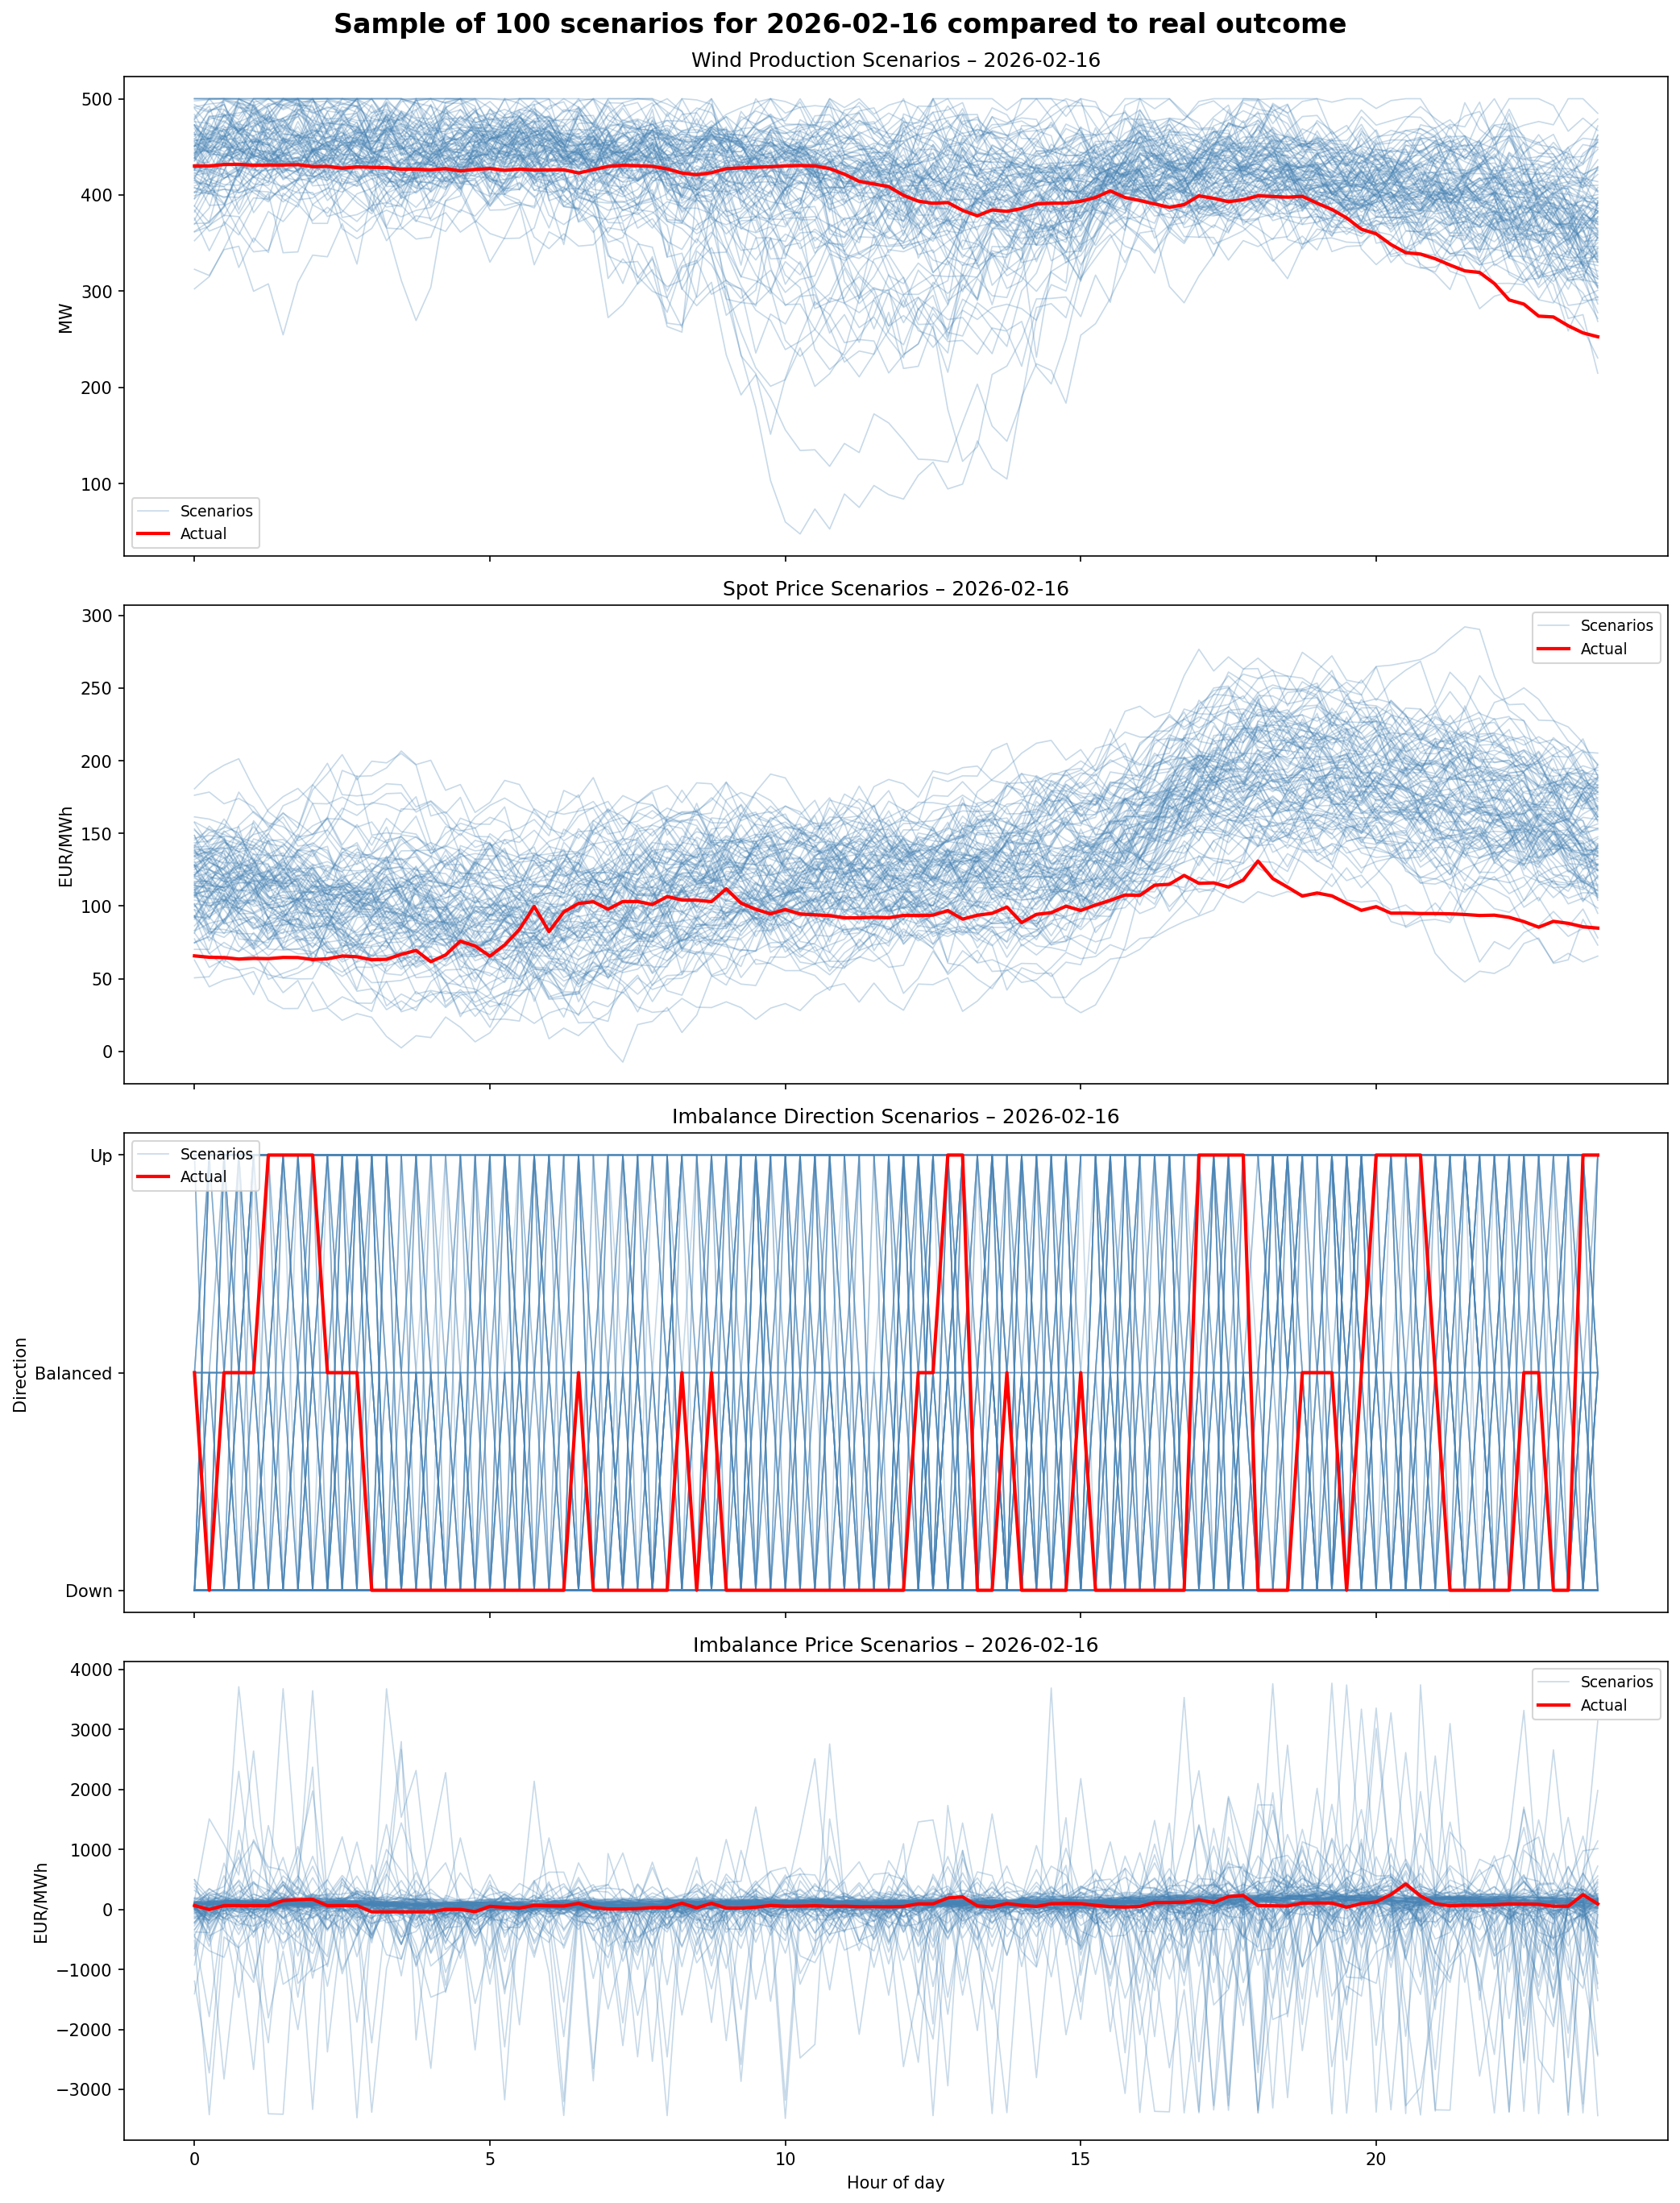

In [9]:
wind_capacity = 500 # MW
n_scenarios = 500
date = '2026-02-16'

scenarios = generate_scenarios_for_date(df, date, n_scenarios=n_scenarios, wind_capacity=wind_capacity)
plot_scenarios_and_actuals(df, date, scenarios, wind_capacity, n_plot_scenarios=100)